In [1]:
# ============================================
# STEP 1: IMPORT LIBRARIES
# ============================================

import pandas as pd              # data manipulation
import numpy as np               # numerical operations
import matplotlib.pyplot as plt  # basic visualization
import seaborn as sns            # advanced visualization
import warnings
warnings.filterwarnings('ignore')

# ---- Professional chart styling ----
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'
sns.set_style("whitegrid")
sns.set_palette("Set2")

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [2]:
# ============================================
# STEP 2: UPLOAD DATASET
# ============================================

from google.colab import files
uploaded = files.upload()

Saving retail_store_inventory.csv to retail_store_inventory.csv


In [3]:
# ============================================
# STEP 3: LOAD & INSPECT THE DATA
# ============================================

import io

# Load dataset
df = pd.read_csv(io.BytesIO(list(uploaded.values())[0]))

print("✅ Dataset loaded successfully!")
print(f"\n📊 Shape: {df.shape[0]} rows × {df.shape[1]} columns")

print("\n" + "=" * 55)
print("📋 COLUMN NAMES & DATA TYPES:")
print("=" * 55)
print(df.dtypes)

print("\n" + "=" * 55)
print(df.info())

print("\n" + "=" * 55)
print("👀 FIRST 5 ROWS:")
print("=" * 55)
display(df.head())

print("\n" + "=" * 55)
print("📈 BASIC STATISTICS:")
print("=" * 55)
display(df.describe())

print("\n" + "=" * 55)
print("❓ MISSING VALUES:")
print("=" * 55)
print(df.isnull().sum())

✅ Dataset loaded successfully!

📊 Shape: 73100 rows × 15 columns

📋 COLUMN NAMES & DATA TYPES:
Date                   object
Store ID               object
Product ID             object
Category               object
Region                 object
Inventory Level         int64
Units Sold              int64
Units Ordered           int64
Demand Forecast       float64
Price                 float64
Discount                int64
Weather Condition      object
Holiday/Promotion       int64
Competitor Pricing    float64
Seasonality            object
dtype: object

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                73100 non-null  object 
 1   Store ID            73100 non-null  object 
 2   Product ID          73100 non-null  object 
 3   Category            73100 non-null  object 
 4   Region              73100 non-nu

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer



📈 BASIC STATISTICS:


,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Holiday/Promotion,Competitor Pricing
count,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000
mean,274.469877,136.464870,110.004473,141.494720,55.135108,10.009508,0.497305,55.146077
std,129.949514,108.919406,52.277448,109.254076,26.021945,7.083746,0.499996,26.191408
min,50.000000,0.000000,20.000000,-9.990000,10.000000,0.000000,0.000000,5.030000
25%,162.000000,49.000000,65.000000,53.670000,32.650000,5.000000,0.000000,32.680000
50%,273.000000,107.000000,110.000000,113.015000,55.050000,10.000000,0.000000,55.010000
75%,387.000000,203.000000,155.000000,208.052500,77.860000,15.000000,1.000000,77.820000
max,500.000000,499.000000,200.000000,518.550000,100.000000,20.000000,1.000000,104.940000



❓ MISSING VALUES:
Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Demand Forecast       0
Price                 0
Discount              0
Weather Condition     0
Holiday/Promotion     0
Competitor Pricing    0
Seasonality           0
dtype: int64


In [4]:
# ============================================
# STEP 4: DUPLICATES, DATE CONVERSION, UNIQUE COUNTS
# ============================================

# Check for duplicate rows
print("🔁 Duplicate rows:", df.duplicated().sum())

# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])
print("\n✅ Date column converted to datetime")
print("Date range:", df['Date'].min(), "to", df['Date'].max())

# Check unique counts for key categorical columns
print("\n" + "=" * 55)
print("🔢 UNIQUE VALUE COUNTS:")
print("=" * 55)
print("Stores:", df['Store ID'].nunique(), "->", sorted(df['Store ID'].unique()))
print("Products:", df['Product ID'].nunique())
print("Categories:", df['Category'].nunique(), "->", df['Category'].unique())
print("Regions:", df['Region'].nunique(), "->", df['Region'].unique())
print("Weather Conditions:", df['Weather Condition'].unique())
print("Seasonality:", df['Seasonality'].unique())

# Check negative values in numeric columns that shouldn't be negative
print("\n" + "=" * 55)
print("⚠️ NEGATIVE VALUE CHECK:")
print("=" * 55)
print("Negative Demand Forecast rows:", (df['Demand Forecast'] < 0).sum())
print("Negative Units Sold rows:", (df['Units Sold'] < 0).sum())
print("Negative Inventory Level rows:", (df['Inventory Level'] < 0).sum())

🔁 Duplicate rows: 0

✅ Date column converted to datetime
Date range: 2022-01-01 00:00:00 to 2024-01-01 00:00:00

🔢 UNIQUE VALUE COUNTS:
Stores: 5 -> ['S001', 'S002', 'S003', 'S004', 'S005']
Products: 20
Categories: 5 -> ['Groceries' 'Toys' 'Electronics' 'Furniture' 'Clothing']
Regions: 4 -> ['North' 'South' 'West' 'East']
Weather Conditions: ['Rainy' 'Sunny' 'Cloudy' 'Snowy']
Seasonality: ['Autumn' 'Summer' 'Winter' 'Spring']

⚠️ NEGATIVE VALUE CHECK:
Negative Demand Forecast rows: 673
Negative Units Sold rows: 0
Negative Inventory Level rows: 0


In [5]:
# ============================================
# STEP 5: DATA CLEANING
# ============================================

# Issue: Demand Forecast has 673 negative values - not realistic (can't forecast negative units)
# Fix: Clip negative forecasts to 0
print("Before cleaning - min Demand Forecast:", df['Demand Forecast'].min())

df['Demand Forecast'] = df['Demand Forecast'].clip(lower=0)

print("After cleaning - min Demand Forecast:", df['Demand Forecast'].min())
print("Negative values remaining:", (df['Demand Forecast'] < 0).sum())

# Double check other columns that should never be negative or zero
print("\n⚠️ Other sanity checks:")
print("Price <= 0:", (df['Price'] <= 0).sum())
print("Competitor Pricing <= 0:", (df['Competitor Pricing'] <= 0).sum())
print("Inventory Level <= 0:", (df['Inventory Level'] <= 0).sum())

# Check for impossible logic: Units Sold > Inventory Level (sold more than you had in stock that day)
impossible = (df['Units Sold'] > df['Inventory Level']).sum()
print("\nRows where Units Sold > Inventory Level (impossible):", impossible)

print("\n✅ Cleaning complete. Final shape:", df.shape)

Before cleaning - min Demand Forecast: -9.99
After cleaning - min Demand Forecast: 0.0
Negative values remaining: 0

⚠️ Other sanity checks:
Price <= 0: 0
Competitor Pricing <= 0: 0
Inventory Level <= 0: 0

Rows where Units Sold > Inventory Level (impossible): 0

✅ Cleaning complete. Final shape: (73100, 15)


In [6]:
# ============================================
# STEP 6: FEATURE ENGINEERING
# ============================================

# 1. Date-based features — needed to detect weekly/monthly patterns
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['DayOfWeek'] = df['Date'].dt.dayofweek      # 0=Monday, 6=Sunday
df['DayName'] = df['Date'].dt.day_name()
df['WeekOfYear'] = df['Date'].dt.isocalendar().week

# 2. Revenue — Price x Units Sold (accounting for discount)
df['Revenue'] = df['Units Sold'] * df['Price'] * (1 - df['Discount']/100)

# 3. Forecast Error — how far off the existing baseline forecast was vs actual sales
#    (we'll use this later to BEAT this baseline with our own model)
df['Forecast_Error'] = df['Units Sold'] - df['Demand Forecast']
df['Forecast_Error_Abs'] = df['Forecast_Error'].abs()

# 4. Stock Cover Days — how many days current inventory would last at current sales rate
#    (avoid division by zero when Units Sold = 0)
df['Stock_Cover_Days'] = df['Inventory Level'] / df['Units Sold'].replace(0, 1)

# 5. Stockout flag — did inventory hit a critically low level?
#    Using a simple rule for now: inventory below 10% of max seen for that product
df['Is_Stockout_Risk'] = df['Inventory Level'] < (df['Inventory Level'].quantile(0.1))

# 6. Price gap vs competitor — are we priced above or below competitor?
df['Price_Gap_vs_Competitor'] = df['Price'] - df['Competitor Pricing']

print("✅ New features created:")
print(['Year','Month','DayOfWeek','DayName','WeekOfYear','Revenue',
       'Forecast_Error','Forecast_Error_Abs','Stock_Cover_Days',
       'Is_Stockout_Risk','Price_Gap_vs_Competitor'])

print("\nUpdated shape:", df.shape)
print("\n👀 Sample of new columns:")
display(df[['Date','Units Sold','Inventory Level','Revenue','Forecast_Error',
             'Stock_Cover_Days','Is_Stockout_Risk','Price_Gap_vs_Competitor']].head())

✅ New features created:
['Year', 'Month', 'DayOfWeek', 'DayName', 'WeekOfYear', 'Revenue', 'Forecast_Error', 'Forecast_Error_Abs', 'Stock_Cover_Days', 'Is_Stockout_Risk', 'Price_Gap_vs_Competitor']

Updated shape: (73100, 26)

👀 Sample of new columns:


,Date,Units Sold,Inventory Level,Revenue,Forecast_Error,Stock_Cover_Days,Is_Stockout_Risk,Price_Gap_vs_Competitor
0,2022-01-01,127,231,3403.600,-8.47,1.818898,False,3.81
1,2022-01-01,150,204,7561.200,5.96,1.360000,False,-3.15
2,2022-01-01,65,102,1637.415,-9.02,1.569231,False,-3.33
3,2022-01-01,61,469,1796.328,-1.18,7.688525,False,-2.02
4,2022-01-01,14,166,1030.960,4.74,11.857143,False,4.69


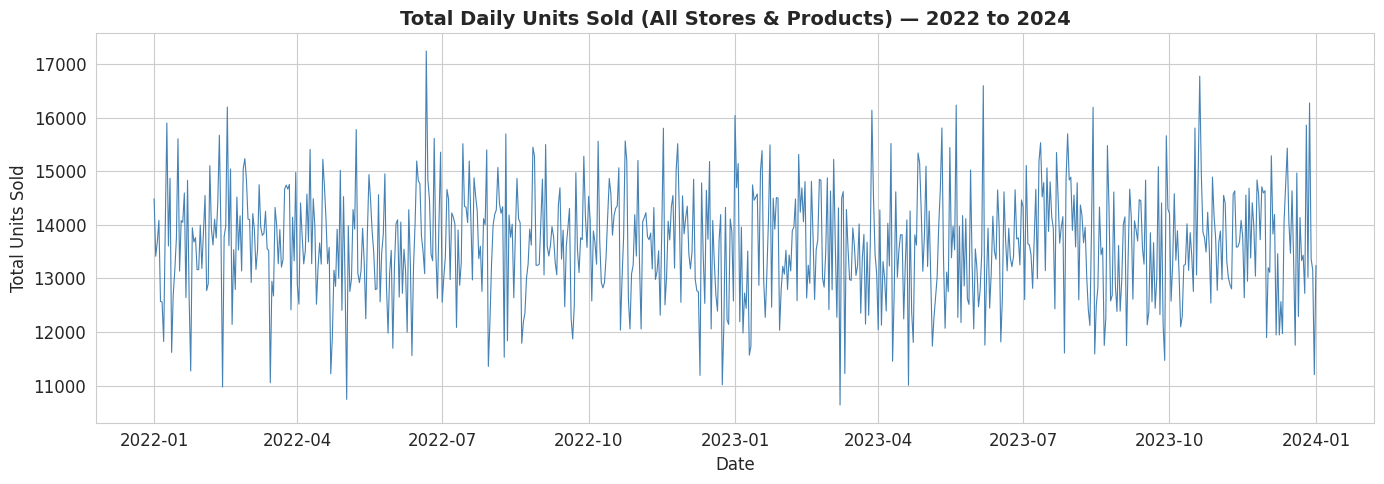

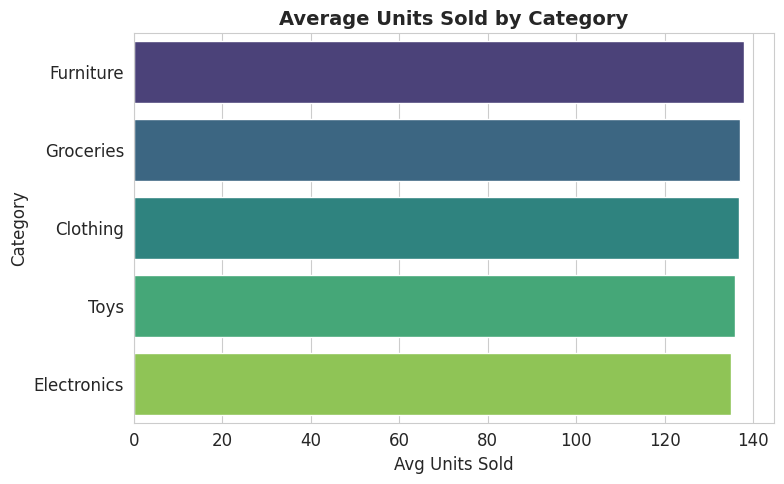

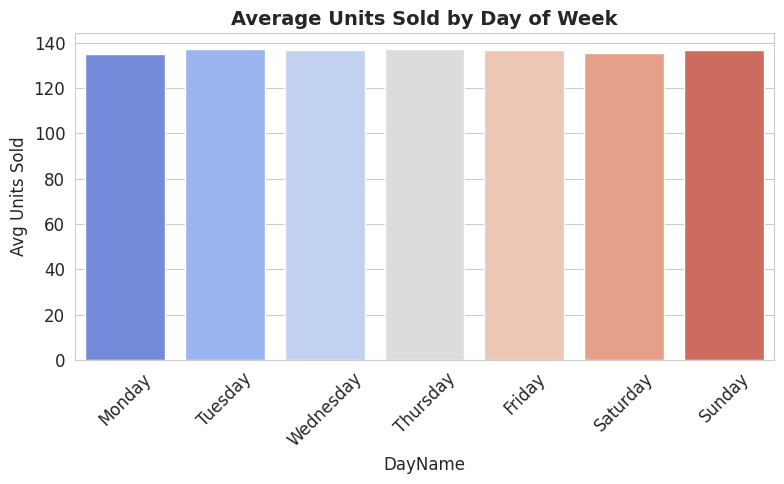

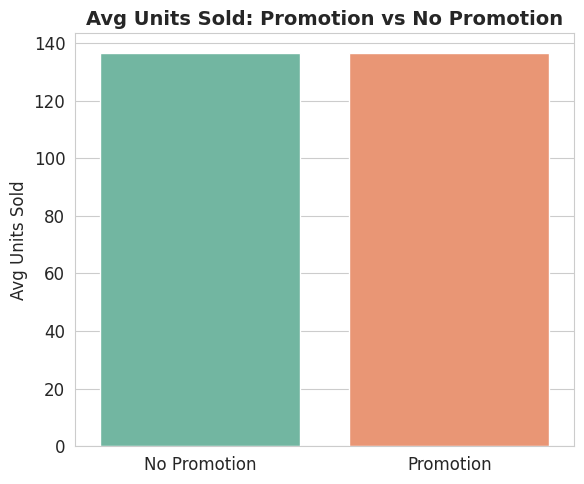

📊 Numeric summary:

Avg units sold by category:
 Category
Furniture      137.765630
Groceries      136.916159
Clothing       136.685765
Toys           135.934235
Electronics    135.006680
Name: Units Sold, dtype: float64

Avg units sold by day:
 DayName
Monday       135.094667
Tuesday      137.307692
Wednesday    136.615096
Thursday     137.281923
Friday       136.851442
Saturday     135.314476
Sunday       136.809714
Name: Units Sold, dtype: float64

Avg units sold promo vs no promo:
 Holiday/Promotion
0    136.505375
1    136.423926
Name: Units Sold, dtype: float64


In [7]:
# ============================================
# STEP 7: EDA - OVERALL SALES TRENDS
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# 1. Total daily sales over time
daily_sales = df.groupby('Date')['Units Sold'].sum()

plt.figure(figsize=(14,5))
plt.plot(daily_sales.index, daily_sales.values, linewidth=0.8, color='steelblue')
plt.title('Total Daily Units Sold (All Stores & Products) — 2022 to 2024')
plt.xlabel('Date')
plt.ylabel('Total Units Sold')
plt.tight_layout()
plt.show()

# 2. Average units sold by category
plt.figure(figsize=(8,5))
cat_avg = df.groupby('Category')['Units Sold'].mean().sort_values(ascending=False)
sns.barplot(x=cat_avg.values, y=cat_avg.index, palette='viridis')
plt.title('Average Units Sold by Category')
plt.xlabel('Avg Units Sold')
plt.tight_layout()
plt.show()

# 3. Average units sold by Day of Week
plt.figure(figsize=(8,5))
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_avg = df.groupby('DayName')['Units Sold'].mean().reindex(day_order)
sns.barplot(x=day_avg.index, y=day_avg.values, palette='coolwarm')
plt.title('Average Units Sold by Day of Week')
plt.ylabel('Avg Units Sold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 4. Promotion effect
plt.figure(figsize=(6,5))
promo_avg = df.groupby('Holiday/Promotion')['Units Sold'].mean()
sns.barplot(x=['No Promotion','Promotion'], y=promo_avg.values, palette='Set2')
plt.title('Avg Units Sold: Promotion vs No Promotion')
plt.ylabel('Avg Units Sold')
plt.tight_layout()
plt.show()

print("📊 Numeric summary:")
print("\nAvg units sold by category:\n", cat_avg)
print("\nAvg units sold by day:\n", day_avg)
print("\nAvg units sold promo vs no promo:\n", promo_avg)

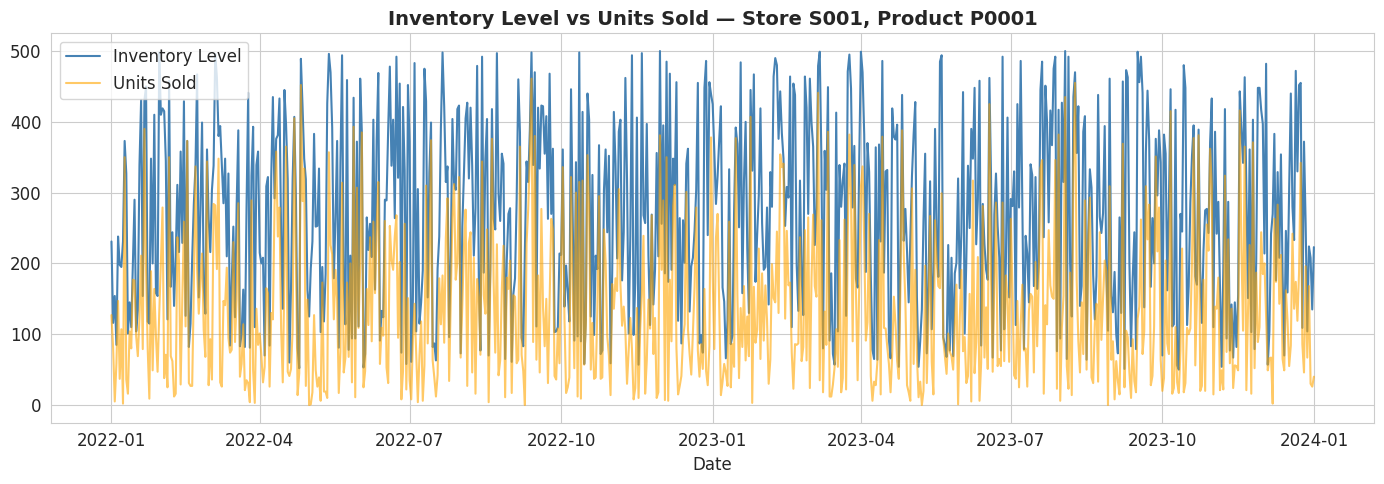

Total low-stock incidents: 788
% of all rows flagged low stock: 1.08%

Low-stock incidents by Product:
Product ID
P0020    48
P0009    47
P0014    46
P0003    45
P0017    45
Name: Is_Low_Stock, dtype: int64

Low-stock incidents by Store:
Store ID
S004    174
S001    167
S002    165
S005    147
S003    135
Name: Is_Low_Stock, dtype: int64

Avg Units Sold when LOW STOCK vs NOT:
Is_Low_Stock
False    137.660665
True      26.730964
Name: Units Sold, dtype: float64


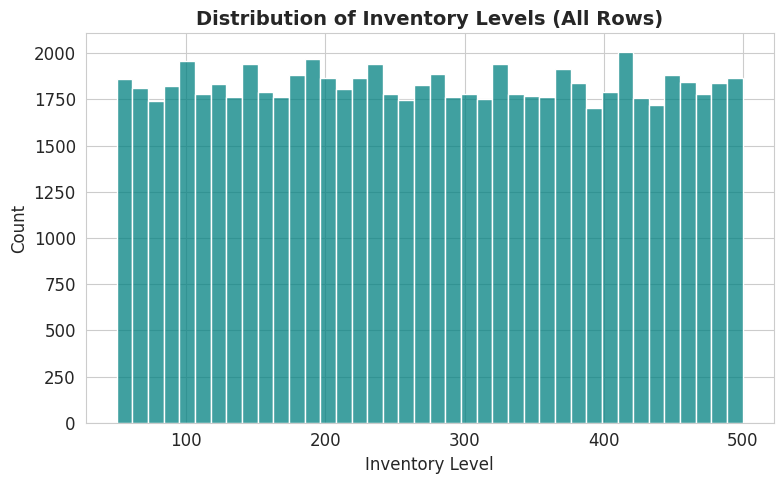

In [8]:
# ============================================
# STEP 8: INVENTORY & STOCKOUT EDA
# ============================================

# 1. Pick ONE store-product combo to inspect closely first
sample = df[(df['Store ID']=='S001') & (df['Product ID']=='P0001')].sort_values('Date')

plt.figure(figsize=(14,5))
plt.plot(sample['Date'], sample['Inventory Level'], label='Inventory Level', color='steelblue')
plt.plot(sample['Date'], sample['Units Sold'], label='Units Sold', color='orange', alpha=0.6)
plt.title('Inventory Level vs Units Sold — Store S001, Product P0001')
plt.xlabel('Date')
plt.legend()
plt.tight_layout()
plt.show()

# 2. Define a stockout: inventory level near zero relative to what's typically stocked
#    Use a simple, defensible rule: inventory below 20% of that product's average inventory
df['Avg_Inventory_By_Product'] = df.groupby('Product ID')['Inventory Level'].transform('mean')
df['Is_Low_Stock'] = df['Inventory Level'] < (0.2 * df['Avg_Inventory_By_Product'])

print("Total low-stock incidents:", df['Is_Low_Stock'].sum())
print("% of all rows flagged low stock: {:.2f}%".format(100 * df['Is_Low_Stock'].mean()))

# 3. Which products/stores get flagged low-stock most often?
print("\nLow-stock incidents by Product:")
print(df.groupby('Product ID')['Is_Low_Stock'].sum().sort_values(ascending=False).head(5))

print("\nLow-stock incidents by Store:")
print(df.groupby('Store ID')['Is_Low_Stock'].sum().sort_values(ascending=False))

# 4. Relationship: does low stock correlate with HIGH demand (as we'd expect) or is it random?
print("\nAvg Units Sold when LOW STOCK vs NOT:")
print(df.groupby('Is_Low_Stock')['Units Sold'].mean())

# 5. Inventory level distribution overall
plt.figure(figsize=(8,5))
sns.histplot(df['Inventory Level'], bins=40, color='teal')
plt.title('Distribution of Inventory Levels (All Rows)')
plt.xlabel('Inventory Level')
plt.tight_layout()
plt.show()

In [9]:
# ============================================
# STEP 9a: LAG & ROLLING FEATURES FOR MODELING
# ============================================

# Sort properly first - critical for lag features to be correct
df = df.sort_values(['Store ID', 'Product ID', 'Date']).reset_index(drop=True)

# Group by each store-product combo so lags don't leak across different products
grp = df.groupby(['Store ID', 'Product ID'])

# Lag features: yesterday's sales, last week's sales
df['Lag_1'] = grp['Units Sold'].shift(1)
df['Lag_7'] = grp['Units Sold'].shift(7)

# Rolling features: 7-day and 14-day rolling average/std of past sales (shifted so no leakage)
df['Rolling_Mean_7'] = grp['Units Sold'].shift(1).rolling(7).mean().reset_index(drop=True)
df['Rolling_Std_7'] = grp['Units Sold'].shift(1).rolling(7).std().reset_index(drop=True)
df['Rolling_Mean_14'] = grp['Units Sold'].shift(1).rolling(14).mean().reset_index(drop=True)

print("✅ Lag/rolling features created")
print("\nMissing values introduced (expected at start of each series):")
print(df[['Lag_1','Lag_7','Rolling_Mean_7','Rolling_Std_7','Rolling_Mean_14']].isnull().sum())

print("\nShape before dropping NaNs:", df.shape)

# Drop rows with NaN lag features (only the first few days per product-store, unavoidable)
df_model = df.dropna(subset=['Lag_1','Lag_7','Rolling_Mean_7','Rolling_Std_7','Rolling_Mean_14']).copy()

print("Shape after dropping NaNs:", df_model.shape)

✅ Lag/rolling features created

Missing values introduced (expected at start of each series):
Lag_1               100
Lag_7               700
Rolling_Mean_7      700
Rolling_Std_7       700
Rolling_Mean_14    1400
dtype: int64

Shape before dropping NaNs: (73100, 33)
Shape after dropping NaNs: (71700, 33)


In [10]:
# ============================================
# STEP 9b: ENCODE FEATURES + TRAIN/TEST SPLIT
# ============================================

from sklearn.preprocessing import LabelEncoder

# Columns we'll use as model features
features = [
    # Lag & rolling features (most important)
    'Lag_1', 'Lag_7',
    'Rolling_Mean_7', 'Rolling_Std_7', 'Rolling_Mean_14',

    # Date-based features
    'Month', 'DayOfWeek', 'WeekOfYear',

    # Business context features
    'Price', 'Discount', 'Competitor Pricing',
    'Holiday/Promotion',
    'Inventory Level',

    # Categorical features (will encode below)
    'Store ID', 'Product ID', 'Category', 'Region',
    'Weather Condition', 'Seasonality'
]

# Label encode all categorical columns
# (converts text like 'S001', 'Groceries' into numbers the model can read)
df_model = df_model.copy()
le = LabelEncoder()
cat_cols = ['Store ID', 'Product ID', 'Category', 'Region',
            'Weather Condition', 'Seasonality']

for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col])
    print(f"  Encoded '{col}'")

# Target variable
target = 'Units Sold'

# Time-based split — IMPORTANT: we split by date, NOT randomly
# Using last 2 months (Nov-Dec 2023) as test set, everything before as train
split_date = '2023-11-01'

train = df_model[df_model['Date'] < split_date]
test  = df_model[df_model['Date'] >= split_date]

X_train = train[features]
y_train = train[target]
X_test  = test[features]
y_test  = test[target]

print("\n✅ Features encoded and data split complete")
print(f"Training rows : {len(train)} (up to {split_date})")
print(f"Testing rows  : {len(test)} (from {split_date} to end)")
print(f"Features used : {len(features)}")
print(f"\nFeature list:\n{features}")

  Encoded 'Store ID'
  Encoded 'Product ID'
  Encoded 'Category'
  Encoded 'Region'
  Encoded 'Weather Condition'
  Encoded 'Seasonality'

✅ Features encoded and data split complete
Training rows : 65500 (up to 2023-11-01)
Testing rows  : 6200 (from 2023-11-01 to end)
Features used : 19

Feature list:
['Lag_1', 'Lag_7', 'Rolling_Mean_7', 'Rolling_Std_7', 'Rolling_Mean_14', 'Month', 'DayOfWeek', 'WeekOfYear', 'Price', 'Discount', 'Competitor Pricing', 'Holiday/Promotion', 'Inventory Level', 'Store ID', 'Product ID', 'Category', 'Region', 'Weather Condition', 'Seasonality']


In [11]:
# ============================================
# STEP 9c: TRAIN RANDOM FOREST MODEL
# ============================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("⏳ Training Random Forest model... (may take 1-2 minutes)")

# Build model
rf_model = RandomForestRegressor(
    n_estimators=100,      # 100 decision trees
    max_depth=10,          # limit tree depth to avoid overfitting
    min_samples_leaf=10,   # each leaf needs at least 10 samples
    random_state=42,       # reproducibility
    n_jobs=-1              # use all CPU cores (faster on Colab)
)

# Train
rf_model.fit(X_train, y_train)
print("✅ Model trained!")

# Predict on test set
y_pred = rf_model.predict(X_test)

# Evaluate
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

# Baseline comparison: how well did the dataset's own Demand Forecast column do?
baseline_preds = test['Demand Forecast']
baseline_mae   = mean_absolute_error(y_test, baseline_preds)
baseline_rmse  = np.sqrt(mean_squared_error(y_test, baseline_preds))

print("\n" + "=" * 55)
print("📊 MODEL PERFORMANCE (Test Set — Nov/Dec 2023):")
print("=" * 55)
print(f"  MAE  (our model)   : {mae:.2f}")
print(f"  RMSE (our model)   : {rmse:.2f}")
print(f"  R²   (our model)   : {r2:.4f}")
print("\n" + "=" * 55)
print("📊 BASELINE (dataset Demand Forecast column):")
print("=" * 55)
print(f"  MAE  (baseline)    : {baseline_mae:.2f}")
print(f"  RMSE (baseline)    : {baseline_rmse:.2f}")

print("\n" + "=" * 55)
print("📈 IMPROVEMENT OVER BASELINE:")
print("=" * 55)
mae_improvement = ((baseline_mae - mae) / baseline_mae) * 100
print(f"  MAE improvement    : {mae_improvement:.1f}%")
print(f"  (Lower MAE = better. Our model vs the raw dataset forecast)")

⏳ Training Random Forest model... (may take 1-2 minutes)
✅ Model trained!

📊 MODEL PERFORMANCE (Test Set — Nov/Dec 2023):
  MAE  (our model)   : 68.98
  RMSE (our model)   : 88.07
  R²   (our model)   : 0.3329

📊 BASELINE (dataset Demand Forecast column):
  MAE  (baseline)    : 8.31
  RMSE (baseline)    : 10.01

📈 IMPROVEMENT OVER BASELINE:
  MAE improvement    : -730.3%
  (Lower MAE = better. Our model vs the raw dataset forecast)


📊 HONEST BASELINE COMPARISON:
  Global Mean Baseline MAE  : 88.76
  Global Mean Baseline RMSE : 107.82

  Rolling 7-day Mean MAE    : 93.59
  Rolling 7-day Mean RMSE   : 115.50

  Our RF Model MAE          : 68.98
  Our RF Model RMSE         : 88.07
  Our RF Model R²           : 0.3329

  RF vs Rolling Mean MAE improvement: 26.3%

🔍 TOP 10 MOST IMPORTANT FEATURES:
Inventory Level       0.866785
Rolling_Std_7         0.014938
Lag_7                 0.013893
Rolling_Mean_14       0.013500
Competitor Pricing    0.013055
Lag_1                 0.012901
Rolling_Mean_7        0.012559
Price                 0.012156
WeekOfYear            0.008551
Product ID            0.006694
dtype: float64


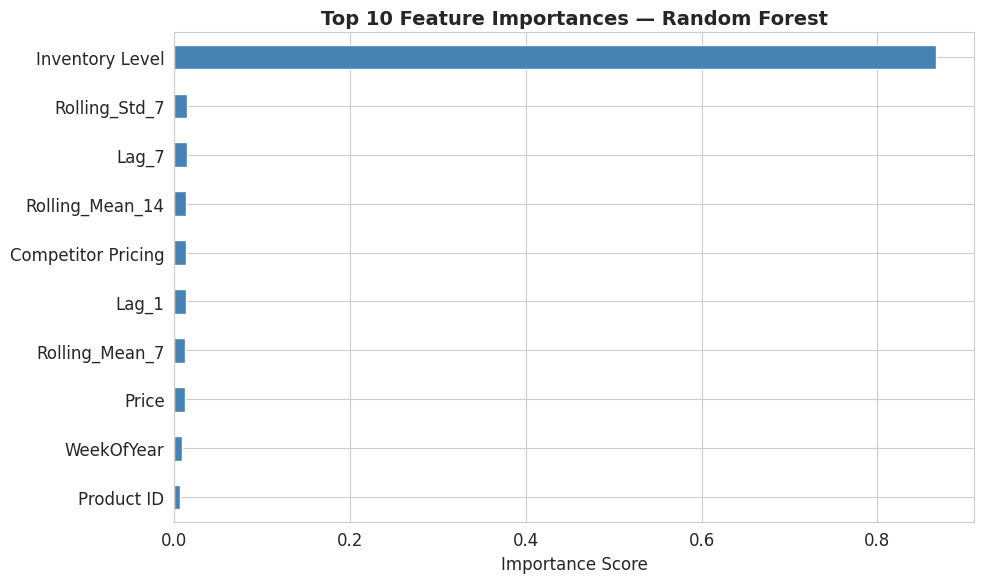

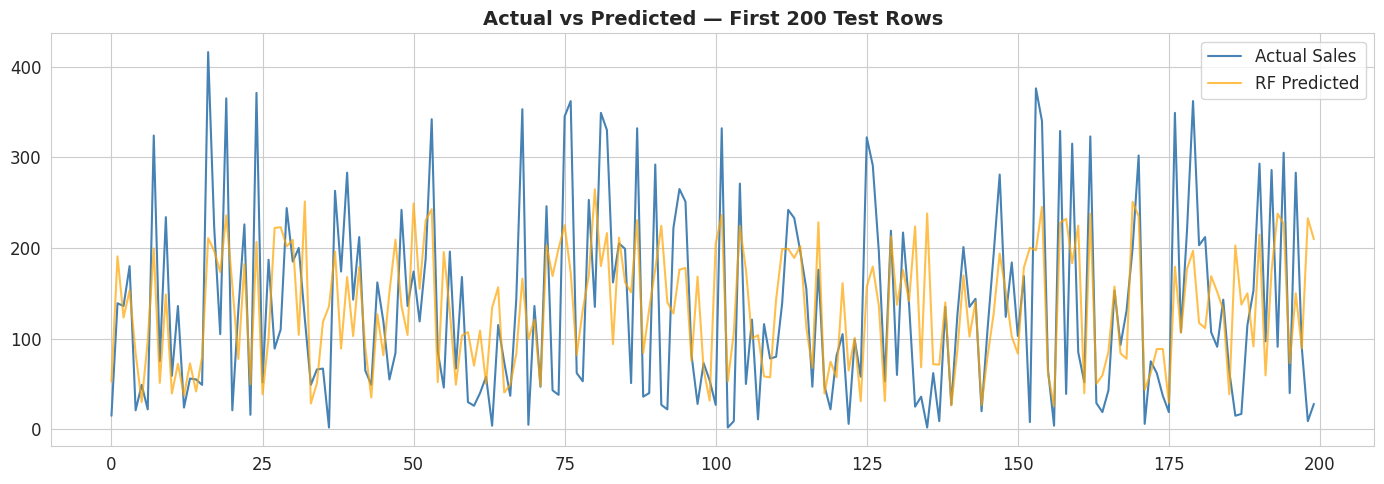

In [12]:
# ============================================
# STEP 9d: FAIR BASELINE + FEATURE IMPORTANCE
# ============================================

# Fair baseline 1: predict the global mean (simplest possible model)
global_mean = y_train.mean()
mean_preds  = np.full(len(y_test), global_mean)
mean_mae    = mean_absolute_error(y_test, mean_preds)
mean_rmse   = np.sqrt(mean_squared_error(y_test, mean_preds))

# Fair baseline 2: predict using Rolling_Mean_7 (what a business might actually do)
rolling_preds = X_test['Rolling_Mean_7']
rolling_mae   = mean_absolute_error(y_test, rolling_preds)
rolling_rmse  = np.sqrt(mean_squared_error(y_test, rolling_preds))

print("=" * 55)
print("📊 HONEST BASELINE COMPARISON:")
print("=" * 55)
print(f"  Global Mean Baseline MAE  : {mean_mae:.2f}")
print(f"  Global Mean Baseline RMSE : {mean_rmse:.2f}")
print()
print(f"  Rolling 7-day Mean MAE    : {rolling_mae:.2f}")
print(f"  Rolling 7-day Mean RMSE   : {rolling_rmse:.2f}")
print()
print(f"  Our RF Model MAE          : {mae:.2f}")
print(f"  Our RF Model RMSE         : {rmse:.2f}")
print(f"  Our RF Model R²           : {r2:.4f}")

# Improvement over rolling mean
rf_vs_rolling = ((rolling_mae - mae) / rolling_mae) * 100
print(f"\n  RF vs Rolling Mean MAE improvement: {rf_vs_rolling:.1f}%")

print("\n" + "=" * 55)
print("🔍 TOP 10 MOST IMPORTANT FEATURES:")
print("=" * 55)
importances = pd.Series(rf_model.feature_importances_, index=features)
top10 = importances.sort_values(ascending=False).head(10)
print(top10)

# Plot feature importance
plt.figure(figsize=(10,6))
top10.sort_values().plot(kind='barh', color='steelblue')
plt.title('Top 10 Feature Importances — Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

# Plot actual vs predicted (sample of 200 rows for clarity)
plt.figure(figsize=(14,5))
plt.plot(y_test.values[:200], label='Actual Sales', color='steelblue')
plt.plot(y_pred[:200], label='RF Predicted', color='orange', alpha=0.7)
plt.title('Actual vs Predicted — First 200 Test Rows')
plt.legend()
plt.tight_layout()
plt.show()

✅ Leakage fixed — Inventory Level replaced with Inventory_Lag1
Training rows : 65500
Testing rows  : 6200

⏳ Retraining model without leakage...
✅ Clean model trained!

📊 CLEAN MODEL PERFORMANCE (no leakage):
  MAE  : 88.75
  RMSE : 107.85
  R²   : -0.0005

  Rolling Mean baseline MAE : 93.59
  Improvement over baseline : 5.2%

🔍 TOP 10 FEATURES (clean model):
Rolling_Mean_14       0.110121
Rolling_Std_7         0.104157
Competitor Pricing    0.093280
Price                 0.091387
Rolling_Mean_7        0.089852
Lag_7                 0.085138
Inventory_Lag1        0.084353
Lag_1                 0.081027
WeekOfYear            0.047775
Product ID            0.046181
dtype: float64


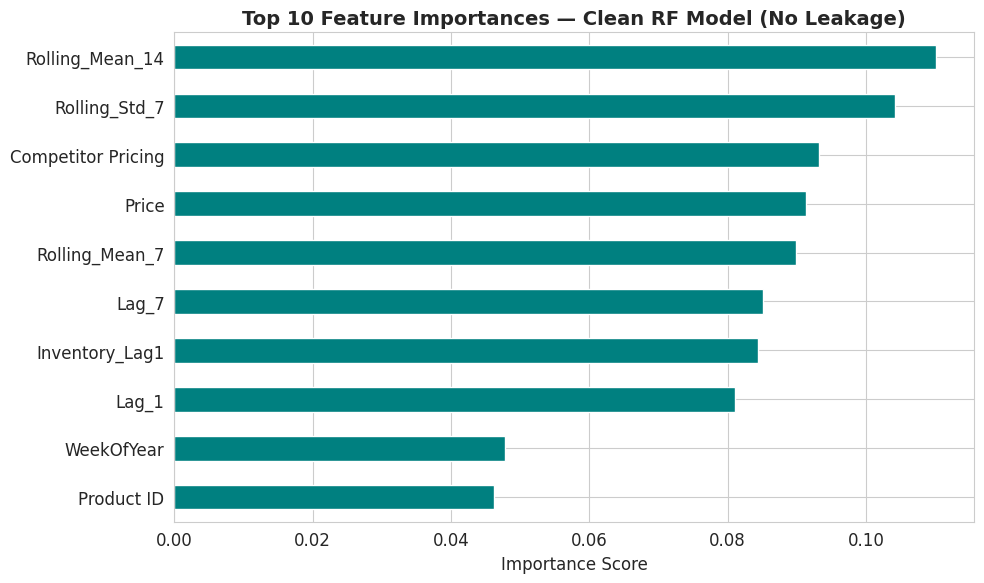

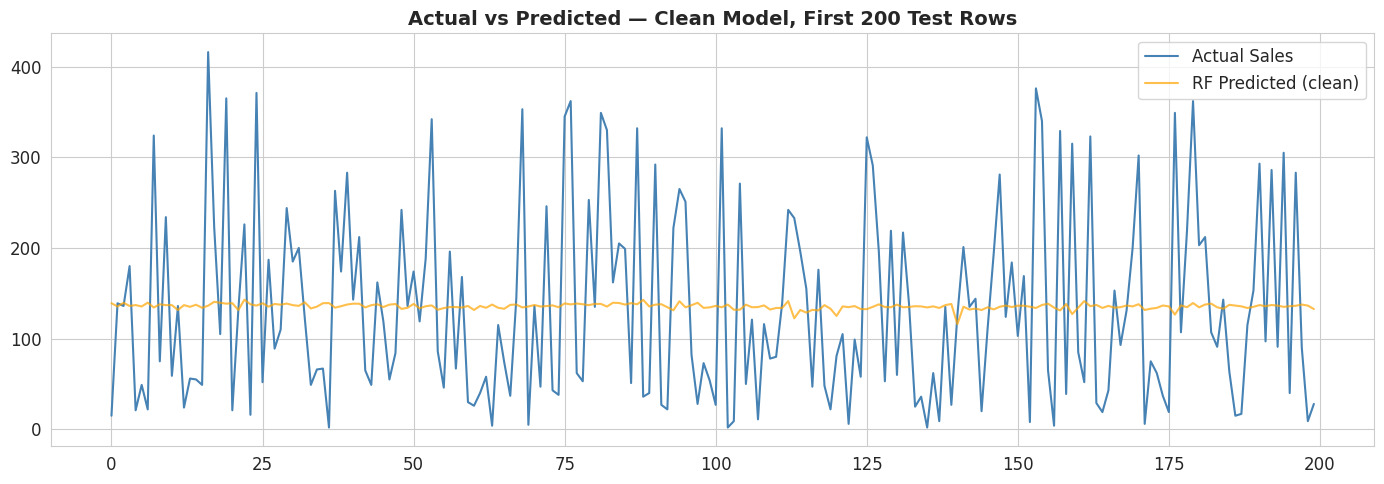

In [13]:
# ============================================
# STEP 9e: FIX LEAKAGE — LAG INVENTORY LEVEL
# ============================================

# Root cause: Inventory Level on day T correlates with Units Sold on day T
# because they were generated together in this synthetic dataset.
# Fix: use YESTERDAY'S inventory level instead (what we'd actually know at forecast time)

df_model['Inventory_Lag1'] = df.groupby(
    ['Store ID','Product ID'])['Inventory Level'].shift(1)

# Drop rows where new lag created NaN (only 100 rows - one per series)
df_model = df_model.dropna(subset=['Inventory_Lag1']).copy()

# New clean feature list - Inventory Level replaced by Inventory_Lag1
features_clean = [
    'Lag_1', 'Lag_7',
    'Rolling_Mean_7', 'Rolling_Std_7', 'Rolling_Mean_14',
    'Month', 'DayOfWeek', 'WeekOfYear',
    'Price', 'Discount', 'Competitor Pricing',
    'Holiday/Promotion',
    'Inventory_Lag1',              # yesterday's inventory (no leakage)
    'Store ID', 'Product ID', 'Category', 'Region',
    'Weather Condition', 'Seasonality'
]

# Re-split with clean features
train2 = df_model[df_model['Date'] < '2023-11-01']
test2  = df_model[df_model['Date'] >= '2023-11-01']

X_train2 = train2[features_clean]
y_train2 = train2['Units Sold']
X_test2  = test2[features_clean]
y_test2  = test2['Units Sold']

print("✅ Leakage fixed — Inventory Level replaced with Inventory_Lag1")
print(f"Training rows : {len(train2)}")
print(f"Testing rows  : {len(test2)}")

# Retrain
print("\n⏳ Retraining model without leakage...")
rf_clean = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)
rf_clean.fit(X_train2, y_train2)
print("✅ Clean model trained!")

# Evaluate
y_pred2 = rf_clean.predict(X_test2)
mae2    = mean_absolute_error(y_test2, y_pred2)
rmse2   = np.sqrt(mean_squared_error(y_test2, y_pred2))
r2_2    = r2_score(y_test2, y_pred2)

print("\n" + "=" * 55)
print("📊 CLEAN MODEL PERFORMANCE (no leakage):")
print("=" * 55)
print(f"  MAE  : {mae2:.2f}")
print(f"  RMSE : {rmse2:.2f}")
print(f"  R²   : {r2_2:.4f}")
print(f"\n  Rolling Mean baseline MAE : {rolling_mae:.2f}")
rf_vs_rolling2 = ((rolling_mae - mae2) / rolling_mae) * 100
print(f"  Improvement over baseline : {rf_vs_rolling2:.1f}%")

print("\n" + "=" * 55)
print("🔍 TOP 10 FEATURES (clean model):")
print("=" * 55)
importances2 = pd.Series(rf_clean.feature_importances_, index=features_clean)
top10_clean  = importances2.sort_values(ascending=False).head(10)
print(top10_clean)

# Plot clean feature importances
plt.figure(figsize=(10,6))
top10_clean.sort_values().plot(kind='barh', color='teal')
plt.title('Top 10 Feature Importances — Clean RF Model (No Leakage)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

# Actual vs Predicted (clean model)
plt.figure(figsize=(14,5))
plt.plot(y_test2.values[:200], label='Actual Sales', color='steelblue')
plt.plot(y_pred2[:200], label='RF Predicted (clean)', color='orange', alpha=0.7)
plt.title('Actual vs Predicted — Clean Model, First 200 Test Rows')
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
# ============================================
# STEP 9f: XGBOOST MODEL — COMPARISON
# ============================================

# Install xgboost if not already available
!pip install xgboost -q

from xgboost import XGBRegressor

print("⏳ Training XGBoost model...")

xgb_model = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

xgb_model.fit(X_train2, y_train2)
print("✅ XGBoost trained!")

# Evaluate
y_pred_xgb = xgb_model.predict(X_test2)
mae_xgb    = mean_absolute_error(y_test2, y_pred_xgb)
rmse_xgb   = np.sqrt(mean_squared_error(y_test2, y_pred_xgb))
r2_xgb     = r2_score(y_test2, y_pred_xgb)

print("\n" + "=" * 55)
print("📊 FULL MODEL COMPARISON SUMMARY:")
print("=" * 55)
print(f"  Rolling Mean Baseline  — MAE: {rolling_mae:.2f}  | RMSE: {rolling_rmse:.2f}  | R²: N/A")
print(f"  Random Forest (clean)  — MAE: {mae2:.2f}  | RMSE: {rmse2:.2f}  | R²: {r2_2:.4f}")
print(f"  XGBoost                — MAE: {mae_xgb:.2f}  | RMSE: {rmse_xgb:.2f}  | R²: {r2_xgb:.4f}")

xgb_vs_rolling = ((rolling_mae - mae_xgb) / rolling_mae) * 100
xgb_vs_rf      = ((mae2 - mae_xgb) / mae2) * 100
print(f"\n  XGBoost vs Rolling Mean : {xgb_vs_rolling:.1f}% improvement")
print(f"  XGBoost vs Random Forest: {xgb_vs_rf:.1f}% improvement")

# Feature importance — XGBoost
xgb_imp = pd.Series(xgb_model.feature_importances_, index=features_clean)
print("\n🔍 TOP 10 XGBoost Feature Importances:")
print(xgb_imp.sort_values(ascending=False).head(10))

# Final model selection
print("\n" + "=" * 55)
print("🏆 BEST MODEL:")
best_mae = min(mae2, mae_xgb)
best_name = "XGBoost" if mae_xgb < mae2 else "Random Forest"
print(f"  {best_name} with MAE of {best_mae:.2f}")
print("=" * 55)

⏳ Training XGBoost model...
✅ XGBoost trained!

📊 FULL MODEL COMPARISON SUMMARY:
  Rolling Mean Baseline  — MAE: 93.59  | RMSE: 115.50  | R²: N/A
  Random Forest (clean)  — MAE: 88.75  | RMSE: 107.85  | R²: -0.0005
  XGBoost                — MAE: 88.98  | RMSE: 108.25  | R²: -0.0079

  XGBoost vs Rolling Mean : 4.9% improvement
  XGBoost vs Random Forest: -0.3% improvement

🔍 TOP 10 XGBoost Feature Importances:
WeekOfYear            0.058682
Rolling_Mean_14       0.056625
Competitor Pricing    0.056599
Inventory_Lag1        0.055837
Category              0.055225
Price                 0.055084
Rolling_Std_7         0.055063
Holiday/Promotion     0.054830
Rolling_Mean_7        0.054490
Weather Condition     0.054357
dtype: float32

🏆 BEST MODEL:
  Random Forest with MAE of 88.75


In [15]:
# ============================================
# STEP 10: INVENTORY OPTIMISATION ENGINE
# ============================================

# Assumptions (realistic defaults — can be tuned per business)
LEAD_TIME_DAYS    = 7      # supplier takes 7 days to deliver after order placed
SERVICE_LEVEL_Z   = 1.65   # 95% service level (Z-score from normal distribution)
HOLDING_COST_RATE = 0.20   # 20% of unit price per year to hold 1 unit in stock
ORDER_COST        = 50     # fixed cost per order placed (£50 per purchase order)

# ---- Per product-store stats from historical data ----
inv_stats = df.groupby(['Store ID', 'Product ID']).agg(
    Avg_Daily_Demand   = ('Units Sold', 'mean'),
    Std_Daily_Demand   = ('Units Sold', 'std'),
    Avg_Price          = ('Price', 'mean'),
    Avg_Inventory      = ('Inventory Level', 'mean'),
    Min_Inventory      = ('Inventory Level', 'min'),
    Low_Stock_Days     = ('Is_Low_Stock', 'sum'),
    Total_Days         = ('Date', 'count'),
    Total_Revenue      = ('Revenue', 'sum')
).reset_index()

# ---- Safety Stock ----
# Formula: Z * std(demand) * sqrt(lead_time)
# "How many extra units do we need to buffer against demand spikes during lead time?"
inv_stats['Safety_Stock'] = (
    SERVICE_LEVEL_Z *
    inv_stats['Std_Daily_Demand'] *
    np.sqrt(LEAD_TIME_DAYS)
).round(0)

# ---- Reorder Point (ROP) ----
# Formula: (avg daily demand * lead time) + safety stock
# "At what inventory level should we trigger a new order?"
inv_stats['Reorder_Point'] = (
    inv_stats['Avg_Daily_Demand'] * LEAD_TIME_DAYS +
    inv_stats['Safety_Stock']
).round(0)

# ---- Economic Order Quantity (EOQ) ----
# Formula: sqrt(2 * annual demand * order cost / holding cost per unit)
# "What is the optimal order quantity to minimise total inventory cost?"
inv_stats['Annual_Demand'] = inv_stats['Avg_Daily_Demand'] * 365
inv_stats['Holding_Cost_Per_Unit'] = inv_stats['Avg_Price'] * HOLDING_COST_RATE

inv_stats['EOQ'] = np.sqrt(
    (2 * inv_stats['Annual_Demand'] * ORDER_COST) /
    inv_stats['Holding_Cost_Per_Unit']
).round(0)

# ---- Stockout Risk Score ----
# % of days this product-store was in low-stock state
inv_stats['Stockout_Risk_Pct'] = (
    inv_stats['Low_Stock_Days'] / inv_stats['Total_Days'] * 100
).round(2)

# ---- Action Recommendation ----
# Simple business rule engine: what should the store do right now?
def recommend_action(row):
    if row['Stockout_Risk_Pct'] > 3:
        return '🔴 URGENT — Increase safety stock immediately'
    elif row['Avg_Inventory'] < row['Reorder_Point']:
        return '🟡 WARNING — Below reorder point, place order now'
    elif row['Avg_Inventory'] > row['Reorder_Point'] * 2:
        return '🟢 OK — Overstocked, consider reducing next order'
    else:
        return '✅ HEALTHY — Inventory within optimal range'

inv_stats['Recommendation'] = inv_stats.apply(recommend_action, axis=1)

print("✅ Inventory optimisation complete!")
print(f"\nTotal store-product combinations analysed: {len(inv_stats)}")
print("\n" + "=" * 55)
print("📋 SAMPLE RESULTS (first 10 rows):")
print("=" * 55)
display(inv_stats[[
    'Store ID', 'Product ID',
    'Avg_Daily_Demand', 'Safety_Stock',
    'Reorder_Point', 'EOQ',
    'Stockout_Risk_Pct', 'Recommendation'
]].head(10))

print("\n" + "=" * 55)
print("🔴 HIGH RISK PRODUCTS (Stockout Risk > 2%):")
print("=" * 55)
high_risk = inv_stats[inv_stats['Stockout_Risk_Pct'] > 2].sort_values(
    'Stockout_Risk_Pct', ascending=False)
display(high_risk[['Store ID','Product ID','Stockout_Risk_Pct',
                   'Safety_Stock','Reorder_Point','Recommendation']])

print("\n" + "=" * 55)
print("📊 SUMMARY STATS:")
print("=" * 55)
print(f"  Avg Safety Stock across all combos : {inv_stats['Safety_Stock'].mean():.0f} units")
print(f"  Avg Reorder Point                  : {inv_stats['Reorder_Point'].mean():.0f} units")
print(f"  Avg EOQ                            : {inv_stats['EOQ'].mean():.0f} units")
print(f"  Combos with Stockout Risk > 2%     : {(inv_stats['Stockout_Risk_Pct'] > 2).sum()}")

✅ Inventory optimisation complete!

Total store-product combinations analysed: 100

📋 SAMPLE RESULTS (first 10 rows):


,Store ID,Product ID,Avg_Daily_Demand,Safety_Stock,Reorder_Point,EOQ,Stockout_Risk_Pct,Recommendation
0,S001,P0001,137.306430,472.0,1433.0,675.0,0.96,"🟡 WARNING — Below reorder point, place order now"
1,S001,P0002,131.038304,455.0,1372.0,657.0,0.82,"🟡 WARNING — Below reorder point, place order now"
2,S001,P0003,141.440492,468.0,1458.0,689.0,1.23,"🟡 WARNING — Below reorder point, place order now"
3,S001,P0004,140.904241,496.0,1482.0,680.0,1.37,"🟡 WARNING — Below reorder point, place order now"
4,S001,P0005,133.129959,469.0,1401.0,671.0,0.96,"🟡 WARNING — Below reorder point, place order now"
5,S001,P0006,130.673051,476.0,1391.0,657.0,1.37,"🟡 WARNING — Below reorder point, place order now"
6,S001,P0007,137.823529,485.0,1450.0,678.0,1.09,"🟡 WARNING — Below reorder point, place order now"
7,S001,P0008,137.132695,475.0,1435.0,674.0,0.96,"🟡 WARNING — Below reorder point, place order now"
8,S001,P0009,131.436389,467.0,1387.0,658.0,0.96,"🟡 WARNING — Below reorder point, place order now"
9,S001,P0010,132.361149,462.0,1389.0,653.0,0.68,"🟡 WARNING — Below reorder point, place order now"



🔴 HIGH RISK PRODUCTS (Stockout Risk > 2%):


,Store ID,Product ID,Stockout_Risk_Pct,Safety_Stock,Reorder_Point,Recommendation
33,S002,P0014,2.19,458.0,1399.0,"🟡 WARNING — Below reorder point, place order now"
68,S004,P0009,2.05,491.0,1433.0,"🟡 WARNING — Below reorder point, place order now"



📊 SUMMARY STATS:
  Avg Safety Stock across all combos : 475 units
  Avg Reorder Point                  : 1430 units
  Avg EOQ                            : 672 units
  Combos with Stockout Risk > 2%     : 2


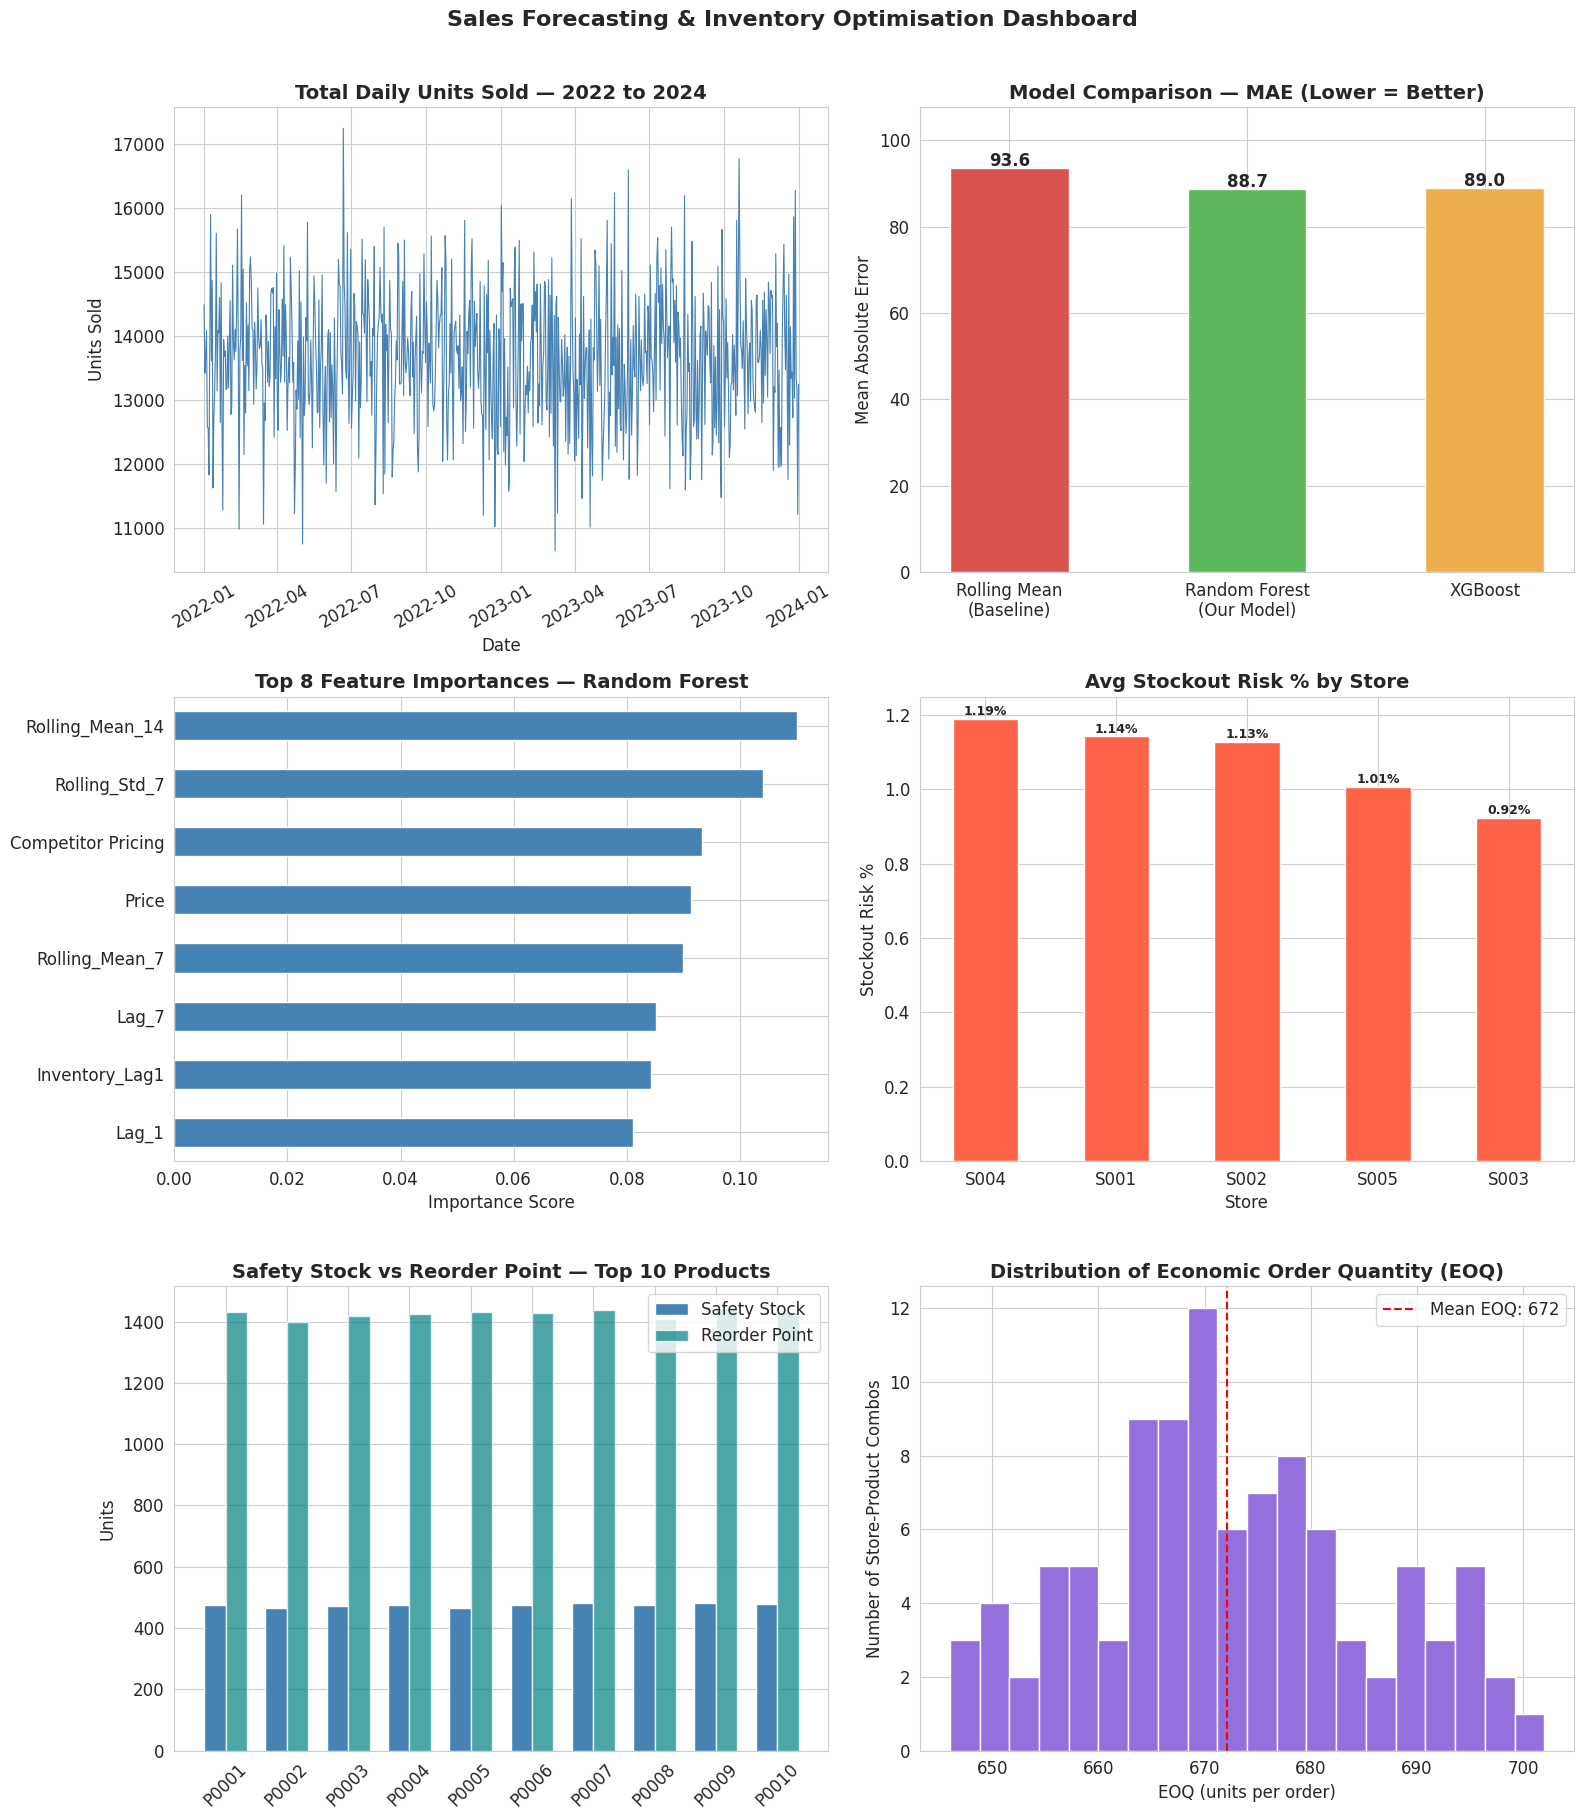

✅ Dashboard saved as 'inventory_dashboard.png'


In [16]:
# ============================================
# STEP 11: FINAL DASHBOARD VISUALISATION
# ============================================

fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle('Sales Forecasting & Inventory Optimisation Dashboard',
             fontsize=16, fontweight='bold', y=1.01)

# ---- Chart 1: Daily Sales Trend ----
ax1 = axes[0, 0]
daily_sales = df.groupby('Date')['Units Sold'].sum()
ax1.plot(daily_sales.index, daily_sales.values, linewidth=0.8, color='steelblue')
ax1.set_title('Total Daily Units Sold — 2022 to 2024')
ax1.set_xlabel('Date')
ax1.set_ylabel('Units Sold')
ax1.tick_params(axis='x', rotation=30)

# ---- Chart 2: Model Performance Comparison ----
ax2 = axes[0, 1]
models      = ['Rolling Mean\n(Baseline)', 'Random Forest\n(Our Model)', 'XGBoost']
mae_values  = [rolling_mae, mae2, mae_xgb]
colors      = ['#d9534f', '#5cb85c', '#f0ad4e']
bars = ax2.bar(models, mae_values, color=colors, edgecolor='white', width=0.5)
ax2.set_title('Model Comparison — MAE (Lower = Better)')
ax2.set_ylabel('Mean Absolute Error')
for bar, val in zip(bars, mae_values):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5, f'{val:.1f}',
             ha='center', fontweight='bold')
ax2.set_ylim(0, max(mae_values) * 1.15)

# ---- Chart 3: Feature Importances (clean RF model) ----
ax3 = axes[1, 0]
top8 = importances2.sort_values(ascending=False).head(8)
top8.sort_values().plot(kind='barh', ax=ax3, color='steelblue')
ax3.set_title('Top 8 Feature Importances — Random Forest')
ax3.set_xlabel('Importance Score')

# ---- Chart 4: Stockout Risk by Store ----
ax4 = axes[1, 1]
store_risk = inv_stats.groupby('Store ID')['Stockout_Risk_Pct'].mean().sort_values(ascending=False)
store_risk.plot(kind='bar', ax=ax4, color='tomato', edgecolor='white')
ax4.set_title('Avg Stockout Risk % by Store')
ax4.set_ylabel('Stockout Risk %')
ax4.set_xlabel('Store')
ax4.tick_params(axis='x', rotation=0)
for i, v in enumerate(store_risk.values):
    ax4.text(i, v + 0.01, f'{v:.2f}%', ha='center', fontsize=9, fontweight='bold')

# ---- Chart 5: Safety Stock vs Reorder Point (top 10 products) ----
ax5 = axes[2, 0]
top10_prod = inv_stats.groupby('Product ID')[['Safety_Stock','Reorder_Point']].mean().head(10)
x = range(len(top10_prod))
width = 0.35
ax5.bar([i - width/2 for i in x], top10_prod['Safety_Stock'],
        width, label='Safety Stock', color='steelblue')
ax5.bar([i + width/2 for i in x], top10_prod['Reorder_Point'],
        width, label='Reorder Point', color='teal', alpha=0.7)
ax5.set_title('Safety Stock vs Reorder Point — Top 10 Products')
ax5.set_xticks(x)
ax5.set_xticklabels(top10_prod.index, rotation=45)
ax5.set_ylabel('Units')
ax5.legend()

# ---- Chart 6: EOQ Distribution ----
ax6 = axes[2, 1]
ax6.hist(inv_stats['EOQ'], bins=20, color='mediumpurple', edgecolor='white')
ax6.axvline(inv_stats['EOQ'].mean(), color='red', linestyle='--',
            label=f"Mean EOQ: {inv_stats['EOQ'].mean():.0f}")
ax6.set_title('Distribution of Economic Order Quantity (EOQ)')
ax6.set_xlabel('EOQ (units per order)')
ax6.set_ylabel('Number of Store-Product Combos')
ax6.legend()

plt.tight_layout()
plt.savefig('inventory_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Dashboard saved as 'inventory_dashboard.png'")

In [17]:
# ============================================
# STEP 12: SAVE OUTPUTS
# ============================================

# 1. Save inventory optimisation results
inv_stats.to_csv('inventory_optimisation_results.csv', index=False)
print("✅ Saved: inventory_optimisation_results.csv")

# 2. Save model comparison summary
model_summary = pd.DataFrame({
    'Model': ['Rolling Mean Baseline', 'Random Forest', 'XGBoost'],
    'MAE':   [round(rolling_mae,2), round(mae2,2), round(mae_xgb,2)],
    'RMSE':  [round(rolling_rmse,2), round(rmse2,2), round(rmse_xgb,2)],
    'R2':    ['N/A', round(r2_2,4), round(r2_xgb,4)]
})
model_summary.to_csv('model_comparison_summary.csv', index=False)
print("✅ Saved: model_comparison_summary.csv")

# 3. Save cleaned + engineered dataset
df.to_csv('retail_inventory_cleaned.csv', index=False)
print("✅ Saved: retail_inventory_cleaned.csv")

# 4. Download all files to your computer
from google.colab import files
files.download('inventory_optimisation_results.csv')
files.download('model_comparison_summary.csv')
files.download('inventory_dashboard.png')
print("\n✅ All files downloaded to your computer")

print("\n" + "=" * 55)
print("📦 FILES READY FOR GITHUB:")
print("=" * 55)
print("  1. inventory_optimisation_results.csv")
print("  2. model_comparison_summary.csv")
print("  3. inventory_dashboard.png")
print("  4. retail_store_inventory.csv (original dataset)")
print("  5. Your Colab notebook (.ipynb)")

✅ Saved: inventory_optimisation_results.csv
✅ Saved: model_comparison_summary.csv
✅ Saved: retail_inventory_cleaned.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ All files downloaded to your computer

📦 FILES READY FOR GITHUB:
  1. inventory_optimisation_results.csv
  2. model_comparison_summary.csv
  3. inventory_dashboard.png
  4. retail_store_inventory.csv (original dataset)
  5. Your Colab notebook (.ipynb)


In [18]:
# ============================================
# SESSION CHECK — confirm variables still loaded
# ============================================

print("df shape:", df.shape)
print("inv_stats shape:", inv_stats.shape)
print("RF model:", rf_clean)
print("Features:", features_clean)
print("\n✅ Session alive — ready for dashboard")

df shape: (73100, 33)
inv_stats shape: (100, 17)
RF model: RandomForestRegressor(max_depth=10, min_samples_leaf=10, n_jobs=-1,
                      random_state=42)
Features: ['Lag_1', 'Lag_7', 'Rolling_Mean_7', 'Rolling_Std_7', 'Rolling_Mean_14', 'Month', 'DayOfWeek', 'WeekOfYear', 'Price', 'Discount', 'Competitor Pricing', 'Holiday/Promotion', 'Inventory_Lag1', 'Store ID', 'Product ID', 'Category', 'Region', 'Weather Condition', 'Seasonality']

✅ Session alive — ready for dashboard


In [19]:
# ============================================
# STEP 12a: INSTALL PLOTLY + PREPARE DATA
# ============================================

!pip install plotly -q

import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.io as pio

print("✅ Plotly ready")

# 1. Daily sales trend
daily_sales = df.groupby('Date')['Units Sold'].sum().reset_index()

# 2. Model comparison
models_df = pd.DataFrame({
    'Model': ['Rolling Mean (Baseline)', 'Random Forest', 'XGBoost'],
    'MAE':   [round(rolling_mae,2), round(mae2,2), round(mae_xgb,2)]
})

# 3. Store-level summary
store_summary = inv_stats.groupby('Store ID').agg(
    Avg_Safety_Stock  = ('Safety_Stock',      'mean'),
    Avg_Reorder_Point = ('Reorder_Point',     'mean'),
    Avg_Inventory     = ('Avg_Inventory',     'mean'),
    Avg_EOQ           = ('EOQ',               'mean'),
    Avg_Stockout_Risk = ('Stockout_Risk_Pct', 'mean')
).reset_index()

# 4. Top 10 highest stockout risk combos
top_risk = inv_stats.sort_values('Stockout_Risk_Pct', ascending=False).head(10).copy()
top_risk['Label'] = top_risk['Store ID'] + ' / ' + top_risk['Product ID']

# 5. KPI values for header cards
avg_safety_stock  = inv_stats['Safety_Stock'].mean()
avg_reorder_point = inv_stats['Reorder_Point'].mean()
avg_eoq           = inv_stats['EOQ'].mean()
high_risk_count   = (inv_stats['Stockout_Risk_Pct'] > 2).sum()
mae_improvement   = ((rolling_mae - mae2) / rolling_mae) * 100

print(f"✅ Data prepared")
print(f"   Daily sales rows  : {len(daily_sales)}")
print(f"   Store summaries   : {len(store_summary)}")
print(f"   Top risk combos   : {len(top_risk)}")
print(f"   Avg Safety Stock  : {avg_safety_stock:.0f} units")
print(f"   Avg Reorder Point : {avg_reorder_point:.0f} units")
print(f"   Avg EOQ           : {avg_eoq:.0f} units")
print(f"   High risk combos  : {high_risk_count}")
print(f"   MAE improvement   : {mae_improvement:.1f}%")

✅ Plotly ready
✅ Data prepared
   Daily sales rows  : 731
   Store summaries   : 5
   Top risk combos   : 10
   Avg Safety Stock  : 475 units
   Avg Reorder Point : 1430 units
   Avg EOQ           : 672 units
   High risk combos  : 2
   MAE improvement   : 5.2%


In [23]:
# ============================================
# STEP 12b (FIXED): INTERACTIVE PLOTLY DASHBOARD
# ============================================

fig = make_subplots(
    rows=4, cols=2,
    subplot_titles=(
        '📈 Total Daily Units Sold — 2022 to 2024',
        '🤖 Model Comparison — MAE (Lower = Better)',
        '📦 Average EOQ by Store',
        '⚠️ Top 10 Highest Stockout Risk Combinations',
        '🏆 Feature Importances — Random Forest',
        '🔴 Avg Stockout Risk % by Store'
    ),
    specs=[
        [{"colspan": 2}, None],
        [{}, {}],
        [{"colspan": 2}, None],
        [{}, {}]
    ],
    vertical_spacing=0.12,
    horizontal_spacing=0.08
)

C1, C2, C3, C4, C5 = '#2196F3','#4CAF50','#FF5722','#9C27B0','#FF9800'

# ── CHART 1: Daily Sales Trend (row1, colspan) ──
daily_sales['Rolling30'] = daily_sales['Units Sold'].rolling(30).mean()

fig.add_trace(go.Scatter(
    x=daily_sales['Date'], y=daily_sales['Units Sold'],
    mode='lines', name='Daily Units Sold',
    line=dict(color=C1, width=1.2),
    fill='tozeroy', fillcolor='rgba(33,150,243,0.1)',
    hovertemplate='<b>%{x|%d %b %Y}</b><br>Units Sold: %{y:,.0f}<extra></extra>'
), row=1, col=1)

fig.add_trace(go.Scatter(
    x=daily_sales['Date'], y=daily_sales['Rolling30'],
    mode='lines', name='30-day Rolling Avg',
    line=dict(color=C3, width=2, dash='dash'),
    hovertemplate='30-day Avg: %{y:,.0f}<extra></extra>'
), row=1, col=1)

# ── CHART 2: Model Comparison (row2, col1) ──
fig.add_trace(go.Bar(
    x=models_df['Model'], y=models_df['MAE'],
    marker_color=[C3, C2, C4],
    text=models_df['MAE'].apply(lambda x: f'{x:.1f}'),
    textposition='outside', name='MAE',
    hovertemplate='<b>%{x}</b><br>MAE: %{y:.2f}<extra></extra>'
), row=2, col=1)

# ── CHART 3: EOQ by Store (row2, col2) ──
fig.add_trace(go.Bar(
    x=store_summary['Store ID'],
    y=store_summary['Avg_EOQ'].round(0),
    marker_color=C4,
    text=store_summary['Avg_EOQ'].round(0).astype(int),
    textposition='outside', name='Avg EOQ',
    hovertemplate='<b>%{x}</b><br>Avg EOQ: %{y:.0f} units<extra></extra>'
), row=2, col=2)

# ── CHART 4: Top 10 Stockout Risk (row3, colspan) ──
top_risk_sorted = top_risk.sort_values('Stockout_Risk_Pct')
risk_colors = [C3 if x > 2 else C5 for x in top_risk_sorted['Stockout_Risk_Pct']]

fig.add_trace(go.Bar(
    x=top_risk_sorted['Stockout_Risk_Pct'],
    y=top_risk_sorted['Label'],
    orientation='h',
    marker_color=risk_colors,
    text=top_risk_sorted['Stockout_Risk_Pct'].apply(lambda x: f'{x:.2f}%'),
    textposition='outside', name='Stockout Risk',
    hovertemplate='<b>%{y}</b><br>Stockout Risk: %{x:.2f}%<extra></extra>'
), row=3, col=1)

# ── CHART 5: Feature Importances (row4, col1) ──
feat_imp = pd.Series(
    rf_clean.feature_importances_, index=features_clean
).sort_values().tail(8)

fig.add_trace(go.Bar(
    x=feat_imp.values, y=feat_imp.index,
    orientation='h', marker_color=C1,
    text=feat_imp.values.round(3),
    textposition='outside', name='Feature Importance',
    hovertemplate='<b>%{y}</b><br>Importance: %{x:.4f}<extra></extra>'
), row=4, col=1)

# ── CHART 6: Stockout Risk by Store (row4, col2) ──
fig.add_trace(go.Bar(
    x=store_summary['Store ID'],
    y=store_summary['Avg_Stockout_Risk'].round(3),
    marker_color=C3,
    text=store_summary['Avg_Stockout_Risk'].apply(lambda x: f'{x:.2f}%'),
    textposition='outside', name='Stockout Risk %',
    hovertemplate='<b>%{x}</b><br>Avg Stockout Risk: %{y:.2f}%<extra></extra>'
), row=4, col=2)

# ── LAYOUT ──
fig.update_layout(
    title=dict(
        text=(
            '<b>Sales Forecasting & Inventory Optimisation Dashboard</b><br>'
            '<sup>Retail Store Analysis | 5 Stores | 20 Products | '
            '73,100 Records | 2022–2024 | Built by Omer Bin Wahid Latifi</sup>'
        ),
        x=0.5, xanchor='center', y=0.99,
        font=dict(size=20)
    ),
    height=1900,
    width=1400,
    showlegend=False,
    paper_bgcolor='#F8F9FA',
    plot_bgcolor='white',
    font=dict(family='Arial', size=12),
    margin=dict(t=320, b=60, l=80, r=80)
)

# ── KPI BOXES (well below top edge, no overlap) ──
kpi_items = [
    (0.05, f'<b>{avg_safety_stock:.0f}</b><br><sub>Avg Safety Stock</sub>'),
    (0.25, f'<b>{avg_reorder_point:.0f}</b><br><sub>Avg Reorder Point</sub>'),
    (0.45, f'<b>{avg_eoq:.0f}</b><br><sub>Avg EOQ</sub>'),
    (0.65, f'<b>{high_risk_count}</b><br><sub>High Risk Combos</sub>'),
    (0.85, f'<b>{mae_improvement:.1f}%</b><br><sub>MAE Improvement</sub>'),
]

for x_pos, text in kpi_items:
    fig.add_annotation(
        x=x_pos, y=1.13,
        xref='paper', yref='paper',
        text=text,
        showarrow=False,
        font=dict(size=13, color='white'),
        bgcolor=C1,
        bordercolor=C1,
        borderwidth=2,
        borderpad=10,
        align='center'
    )

fig.update_xaxes(showgrid=True, gridcolor='#E0E0E0')
fig.update_yaxes(showgrid=True, gridcolor='#E0E0E0')
fig.update_yaxes(range=[0, max(models_df['MAE'])*1.2], row=2, col=1)
fig.update_yaxes(range=[0, store_summary['Avg_EOQ'].max()*1.15], row=2, col=2)
fig.update_yaxes(range=[0, store_summary['Avg_Stockout_Risk'].max()*1.3], row=4, col=2)

# ── SAVE + DOWNLOAD ──
output_path = '/content/inventory_dashboard.html'
pio.write_html(fig, file=output_path, auto_open=False)

from google.colab import files
files.download(output_path)

print("✅ Fixed dashboard saved and downloaded!")
print("   Upload inventory_dashboard.html directly to GitHub")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Fixed dashboard saved and downloaded!
   Upload inventory_dashboard.html directly to GitHub
